In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [2]:
# loading the data
X=np.load('./../Data/InputLorenz63.npz')
Y=np.load('./../Data/OutputLorenz63.npz')
X_input=X['X'] # u
Y_output=Y['dX'] # du/dt
X_tensor=torch.tensor(X_input, dtype=torch.float32)
Y_tensor=torch.tensor(Y_output, dtype=torch.float32)
X_train, X_test, Y_train, Y_test = train_test_split(X_tensor, Y_tensor, test_size=0.2, random_state=42)
train_dataset = data.TensorDataset(X_train, Y_train)
test_dataset  = data.TensorDataset(X_test, Y_test)
train_loader =  data.DataLoader(train_dataset, batch_size=512, shuffle=True)
test_loader  =  data.DataLoader(test_dataset, batch_size=512)



In [3]:
class f_model(nn.Module):
    def __init__(self,N_neurons=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, N_neurons),
            nn.Tanh(),
            nn.Linear(N_neurons, N_neurons),
            nn.Tanh(),
            nn.Linear(N_neurons, N_neurons),
            nn.Tanh(),
            nn.Linear(N_neurons, 3)
        )
    def forward(self, x):
        return self.net(x)
    

In [4]:
# Instantiate the model with 64 neurons per hidden layer
model = f_model(N_neurons=64)

# Use Adam optimizer to update the model's parameters based on gradients
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Define the loss function: Mean Squared Error (averaged over batch)
loss_fn = nn.MSELoss()

# Training loop: run for 100 epochs (full passes over the training dataset)
for epoch in range(100):
    model.train()  # Set the model to training mode (important for layers like dropout or batchnorm)

    total_loss = 0.0  # Accumulator to compute the total loss over the epoch

    # Loop over minibatches from the training DataLoader
    for xb, yb in train_loader:
        # Forward pass: compute predictions for the current batch
        pred = model(xb)

        # Compute the loss between predictions and ground truth
        loss = loss_fn(pred, yb)

        # Zero out the gradients from the previous step
        optimizer.zero_grad()

        # Backward pass: compute gradients of loss w.r.t. model parameters
        loss.backward()

        # Update model parameters using the computed gradients
        optimizer.step()

        # Accumulate weighted batch loss (scaled by batch size) for averaging later
        total_loss += loss.item() * xb.size(0)

    # Compute average loss over the entire dataset
    avg_loss = total_loss / len(train_loader.dataset)

    # Print progress every 10 epochs
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Train Loss: {avg_loss:.6f}")


Epoch 0, Train Loss: 3873.507698
Epoch 10, Train Loss: 1757.384696
Epoch 20, Train Loss: 1047.868029
Epoch 30, Train Loss: 642.317108
Epoch 40, Train Loss: 392.439699
Epoch 50, Train Loss: 243.409055
Epoch 60, Train Loss: 151.671326
Epoch 70, Train Loss: 94.603644
Epoch 80, Train Loss: 58.992802
Epoch 90, Train Loss: 36.836689


In [7]:
model.eval()
test_loss = 0.0
with torch.no_grad():
    for xb, yb in test_loader:
        pred = model(xb)
        test_loss += loss_fn(pred, yb).item() * xb.size(0)

print(f"Test Loss: {test_loss / len(test_loader.dataset):.6f}")


Test Loss: 24.501729


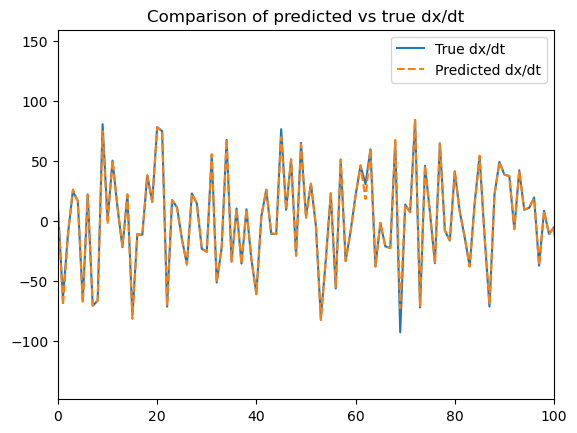

In [12]:
model.eval()
with torch.no_grad():
    preds = model(X_test).numpy()

plt.plot(Y_test.numpy()[:, 0], label='True dx/dt')
plt.plot(preds[:, 0], '--', label='Predicted dx/dt')
plt.legend()
plt.title("Comparison of predicted vs true dx/dt")
plt.xlim(0, 100)
plt.show()
